# <span style="color:rgb(213,80,0)">Create figures 1\-4</span>

In [1]:
rng(10)
clear
format bank


% Fig. number you want to plot
FigNumber=1;


if FigNumber==1


    % Use or not contingency tables which have association in the data
    % generating process
    simulateUnderH0=true;


    % Estimate under H0 or H1
    estimateUnderH0=true;


    % numContRows = number of rows of the contingency table which have been
    % contaminated
    numContRows=0;
    % fracRowCont = fraction of the row which has been contaminated
    % If fracRowCont is 1 all the mass in the row is allocated to the first cell
    fracRowCont=0;


elseif FigNumber==2


    % Use or not contingency tables which have association in the data
    % generating process
    simulateUnderH0=false;


    estimateUnderH0=true;


    % numContRows = number of rows of the contingency table which have been
    % contaminated
    numContRows=0;
    % fracRowCont = fraction of the row which has been contaminated
    % If fracRowCont is 1 all the mass in the row is allocated to the first cell
    fracRowCont=0;


elseif FigNumber==3    % fracRowCont = fraction of the row which has been contaminated


    simulateUnderH0=false;
    estimateUnderH0=false;
    numContRows=0;
    fracRowCont=0;


elseif FigNumber==4    % fracRowCont = fraction of the row which has been contaminated


    simulateUnderH0=false;
    estimateUnderH0=false;
    numContRows=2; %
    fracRowCont=0.3;


else
    error('FSDA:WrngNumber','Just Figures 1-4')
end


## Prepare input for Figures 1\-4

In [2]:
nsimul=1000;
I=20; % Number of rows of the contingency table
J=5; % Number of columns of the contingency table


% Chi2target = Value of Chi2 from which to simulate contingency
% tables (in case simulateUnderH0 is false)
Chi2target=1.1*chi2inv(0.9999,(I-1)*(J-1));


% Simultaneous confidence level to use
conflevSim=0.99;


conflev=1-(1-conflevSim)/I;


% Store the number of simulations with Chi2 greater than the one assumed.
sumSimWithChi2Greater=0;


initperc=0.6;


% In the mcd estimation procedure use or not bands based on alternative
% Example of findEmpiricalEnvelope a struct
findEmp=struct;
% estimateUnderH0=true;
% Under the null hypothesis of independence or under the alternative
findEmp.underH0=estimateUnderH0;


% Generate nsimul contingency tables
findEmp.nsimul=1000;
% Store the nsimul robust distance sorted (for each row)
findEmp.StoreSim=true;




in=0; seqI=1:I;
% Define n
n=10000;


% n/nrow units in each row
nrowt=round(n/I)*ones(I,1);
% n/ncol units in each column
ncolt=round((n/J)*ones(J,1))';
% Generate the contingency table


FSstop=zeros(300,3);
MCDstop=FSstop;




if simulateUnderH0==false
    Ntheo=nrowt*ncolt/n;
    Ntheovec=Ntheo(:);


    % funz2 = anonymous function with 2 input args N and Ntheo
    funz2=@(x,Ntheovec) -sum(((x-Ntheovec).^2)./Ntheovec);
    % funz1 = anonymous function with 1 input arg N which calls funz2
    % The purpose is to minimize funz1 as a function of x
    funz1=@(x)funz2(x,Ntheovec);


    num=I*J;
    lb=zeros(num,1);


    Arows=repmat([ones(1,I) zeros(1,num-I)],J,1);
    AeqRows=Arows;
    for i=2:size(Arows,1)
        AeqRows(i,:)=circshift(AeqRows(i,:),I*(i-1));
    end


    Acols=zeros(I,num);
    AeqCols=Acols;
    seqJ=0:I:(num-J);
    for i=1:I
        AeqCols(i,seqJ+i)=1;
    end


    Aeq=[AeqRows; AeqCols];
    beq=[ncolt'; nrowt];


    optionsFM = optimoptions('fmincon','Display','none');
    % Suppress warning on All Workers
    parfevalOnAll(@warning,0,'off','all');
    warning('off','MATLAB:nearlySingularMatrix');


else
    % Initialization needed for parfor
    funz1=@(x)x;
    Aeq=0; beq=0; lb=0; Chi2target=0;  Ntheovec=0;
    optionsFM=struct;
end


if numContRows>0
    nrowtCont=nrowt;
    ncoltCont=ncolt;
    AmmCont=round(fracRowCont*nrowtCont(1:numContRows));


    nrowtCont(1:numContRows)=nrowtCont(1:numContRows)-AmmCont;
    ncoltCont(1)=ncoltCont(1)-sum(AmmCont);
else
    nrowtCont=nrowt;
    ncoltCont=ncolt;
end


out1=rcontFS(I,J,nrowtCont,ncoltCont,'nocheck',false,'algorithm','144');


N=out1.m144;


if numContRows>0
    N(1:numContRows,1)=N(1:numContRows,1)+AmmCont;
end


init=floor(n*initperc);
onesn1=ones(n,1);


% out1=rcontFS(I,J,nrowt,ncolt,'nocheck',true,'algorithm','144');
x0=out1.m144(:);


if simulateUnderH0==false


    % Chi2current = Chi2 on the simulated contingency table
    Chi2current=-funz2(N(:),Ntheovec);


    if Chi2current<Chi2target


        dd=1;
        while dd>0
            [Nmaxvec, fval] = fmincon(funz1, ...% function to minimize
                x0, ...                    % initial value
                [], [], ...                % no inequality constraint
                Aeq, ...                   %  Aeq  term in -> equality constraint Aeq*x=beq
                beq, ...                   % beq term ->  equality constraint Aeq*x=beq
                lb,[],[],optionsFM);         % all x must be non negative


            % If the condition below is fulfilled we have found a contingency table
            % with a Chi2 value greater than the observed one
            if fval<-Chi2target
                dd=0;
            end
        end


        lambda=1:-0.001:0;
        for i=1:length(lambda)
            Pcandvec=lambda(i)*Ntheovec+(1-lambda(i))*Nmaxvec;
            % disp(-funz1(Pcandvec))
            if funz1(Pcandvec)<-Chi2target
                % disp(lambda(i))
                break
            end
        end
        % N = simulated contingency table with the required value of Chi2
        N=reshape(Pcandvec,I,[]);
    else
        sumSimWithChi2Greater=sumSimWithChi2Greater+1;
        % disp('No further change is needed')
    end
end


## FS analysis

In [3]:
resc=false;
% call to mcdCorAna
RAW=mcdCorAna(N,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev);

Finding empirical bands
Starting parallel pool (parpool) using the 'Threads' profile ...
Connected to parallel pool with 8 workers.

In [4]:
% FS with input the output of CorAna
outFS=FSCorAna(RAW,'plots',0,'msg',0,'StoreSim',false,'conflev',conflevSim,'resc',resc);


## Plots


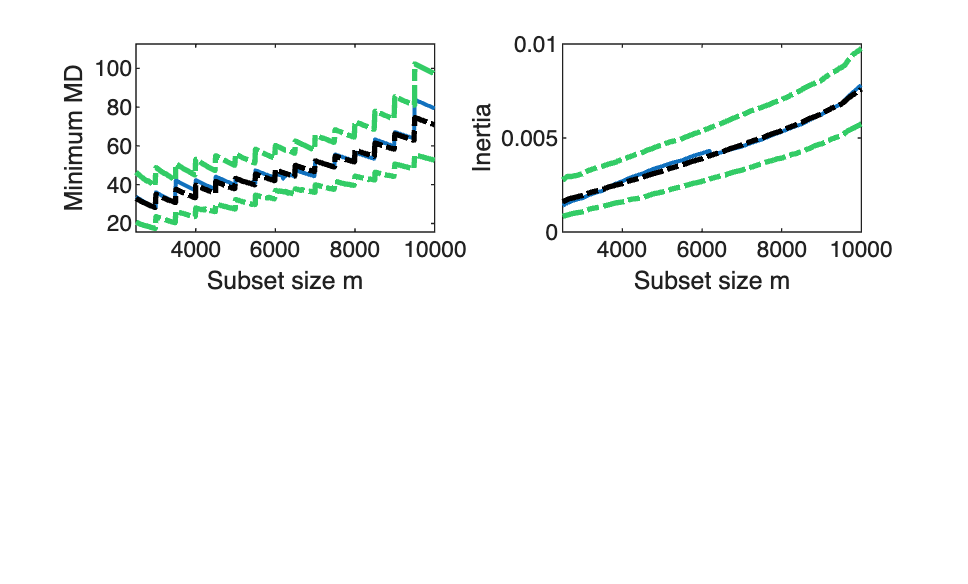

In [5]:
close all
lwdenv=2;
lwdreal=1.5;
subplot(2,2,1)
plot(outFS.mmd(:,1),outFS.mmd(:,2),'LineWidth',lwdreal)


hold on
gmmd=outFS.mmd(:,[1 3:end]);


% Superimpose 50% envelope
line(gmmd(:,1),gmmd(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gmmd(:,1),gmmd(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gmmd(:,1),gmmd(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
X=[outFS.mmd(:,2) gmmd(:,2:end)];
yl1=min(X,[],"all")*0.9;
yl2=max(X,[],"all")*1.1;
ylim([yl1 yl2])
xlabel('Subset size m')
ylabel('Minimum MD')


subplot(2,2,2)
plot(outFS.ine(:,1),outFS.ine(:,2),'LineWidth',lwdreal)


hold on
gine=outFS.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gine(:,1),gine(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gine(:,1),gine(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gine(:,1),gine(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
xlabel('Subset size m')
ylabel('Inertia')

In [6]:


ax=gca;
ax.YAxis.Exponent = 0;


prin=0;
if prin==1
    print -depsc figs\I1.eps;
    print -depsc figs\I2.eps;
    print -depsc figs\I3.eps;
    print -depsc figs\I4.eps;
end